# 04 — Spatial neighbourhood features (GIS)

Per the Zindi ruling in `docs/chats/Neighbouring cells' past TWS — permitted or not.txt` (19 Aug), neighbourhood means/local deviations of `TWS_t` at months ≤ t are explicitly permitted, even though raw lat/lon may never be a model input. One participant in that same thread self-reported RMSE 0.637 → 0.604 from a 500 km neighbourhood mean of the TWS anomaly — cited here only as motivation for *trying* this, not as a number we can reuse; we validate independently on our own split below.

Plan: build a geographic neighbour graph over the 15,715 grid cells (identical set in Train.csv and Test.csv — confirmed in the previous session), compute each cell's same-month neighbourhood mean `TWS_t` and its local deviation (`TWS_t` minus that mean), then run the same controlled before/after comparison used in `03_masked_tws_fill.ipynb`: same model, same split, only the two new columns differ.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.spatial import cKDTree

from src import config, data, evaluate, features, model
from src.train import get_feature_cols

train, test, sample_submission = data.load_raw_data()
feature_cols = get_feature_cols(train)
print("train:", train.shape, "| test:", test.shape)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\alher\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\alher\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\alher\anaconda3\Lib\site-pac

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\alher\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\alher\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\alher\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\alher\anaconda3\Lib\site-pac

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



train: (2154021, 13) | test: (280961, 13)


## Build the geographic neighbour graph

Cells on a 1° grid are converted to 3D unit-sphere coordinates so great-circle distance is exact at every latitude (a naive lat/lon Euclidean distance distorts badly near the poles). Neighbours are every other cell within 500 km, excluding the cell itself. lat/lon are used only here, internally, to build the graph - never passed to the model (`config.FORBIDDEN_MODEL_FEATURES`).

In [2]:
R_EARTH_KM = 6371.0
NEIGHBOUR_RADIUS_KM = 500.0


def latlon_to_unit_sphere(lat_deg, lon_deg):
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    return np.column_stack([x, y, z])


cell_index = (
    pd.concat([train[[config.LAT_COL, config.LON_COL]], test[[config.LAT_COL, config.LON_COL]]])
    .drop_duplicates()
    .reset_index(drop=True)
)
n_cells = len(cell_index)
cell_id = {
    (lat, lon): i
    for i, (lat, lon) in enumerate(zip(cell_index[config.LAT_COL], cell_index[config.LON_COL]))
}

xyz = latlon_to_unit_sphere(cell_index[config.LAT_COL].to_numpy(), cell_index[config.LON_COL].to_numpy())
chord_threshold = 2 * np.sin(NEIGHBOUR_RADIUS_KM / (2 * R_EARTH_KM))

tree = cKDTree(xyz)
neighbour_lists = tree.query_ball_point(xyz, r=chord_threshold)

rows, cols = [], []
for i, neighbours in enumerate(neighbour_lists):
    for j in neighbours:
        if j != i:
            rows.append(i)
            cols.append(j)

adjacency = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(n_cells, n_cells))
neighbour_counts = np.asarray(adjacency.sum(axis=1)).ravel()

print(f"Cells: {n_cells}")
print(f"Avg neighbours: {neighbour_counts.mean():.1f} | min: {neighbour_counts.min():.0f} "
      f"| max: {neighbour_counts.max():.0f} | isolated cells (0 neighbours): {(neighbour_counts == 0).sum()}")


Cells: 15715
Avg neighbours: 87.1 | min: 0 | max: 301 | isolated cells (0 neighbours): 2


## Sanity check: neighbour density map

Where are cells isolated or sparsely connected? Coastlines/islands should show fewer neighbours than continental interiors.

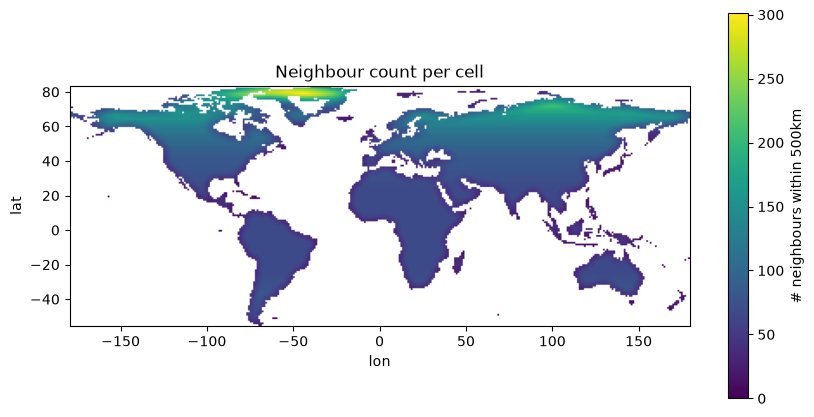

In [3]:
density = cell_index.copy()
density["neighbour_count"] = neighbour_counts
grid = density.pivot(index=config.LAT_COL, columns=config.LON_COL, values="neighbour_count").sort_index().sort_index(axis=1)

plt.figure(figsize=(10, 5))
im = plt.imshow(
    grid.values, cmap="viridis", origin="lower",
    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()],
)
plt.colorbar(im, label="# neighbours within 500km")
plt.title("Neighbour count per cell")
plt.xlabel("lon"); plt.ylabel("lat")
plt.show()


## Same-month neighbourhood mean

For each row, average `TWS_t` over that same cell's neighbours **at the same month** (never an earlier or later one - this is spatial filtering of the current month's own already-available field, not a temporal lookup). Missing/NaN neighbour values are excluded from the average rather than treated as zero.

In [4]:
def add_neighbourhood_features(df: pd.DataFrame, cell_id: dict, adjacency, n_cells: int) -> pd.DataFrame:
    """Add tws_neighbour_mean (same-month spatial average of TWS_t over cells
    within NEIGHBOUR_RADIUS_KM, excluding self) and tws_local_deviation
    (TWS_t - tws_neighbour_mean).

    Source: docs/chats/Neighbouring cells' past TWS - permitted or not.txt
    (Zindi ruling, 19 Aug 2026) - neighbourhood means/local deviations of TWS at
    months <= t are explicitly permitted. lat/lon are used only to build the
    neighbour graph passed in via cell_id/adjacency, never as model features.
    NaN/masked TWS_t values are excluded from each neighbourhood average rather
    than treated as zero.
    """
    out = df.reset_index(drop=True).copy()
    out["_cell_idx"] = [
        cell_id[(lat, lon)] for lat, lon in zip(out[config.LAT_COL], out[config.LON_COL])
    ]

    neighbour_mean = np.full(len(out), np.nan)
    for _, grp in out.groupby(config.TIME_COL):
        idx = grp["_cell_idx"].to_numpy()
        values = grp[config.TWS_COL].to_numpy()
        valid = ~np.isnan(values)

        month_vec = np.zeros(n_cells)
        month_vec[idx[valid]] = values[valid]
        present = np.zeros(n_cells)
        present[idx[valid]] = 1.0

        weighted_sum = adjacency @ month_vec
        weight = adjacency @ present
        with np.errstate(invalid="ignore", divide="ignore"):
            cell_mean = np.where(weight > 0, weighted_sum / weight, np.nan)

        neighbour_mean[grp.index.to_numpy()] = cell_mean[idx]

    out["tws_neighbour_mean"] = neighbour_mean
    out["tws_local_deviation"] = out[config.TWS_COL] - out["tws_neighbour_mean"]
    return out.drop(columns=["_cell_idx"])


## Sanity check: does it actually smooth?

Raw `TWS_t` vs. its neighbourhood mean for one month - the mean should look like a blurred version of the raw field.

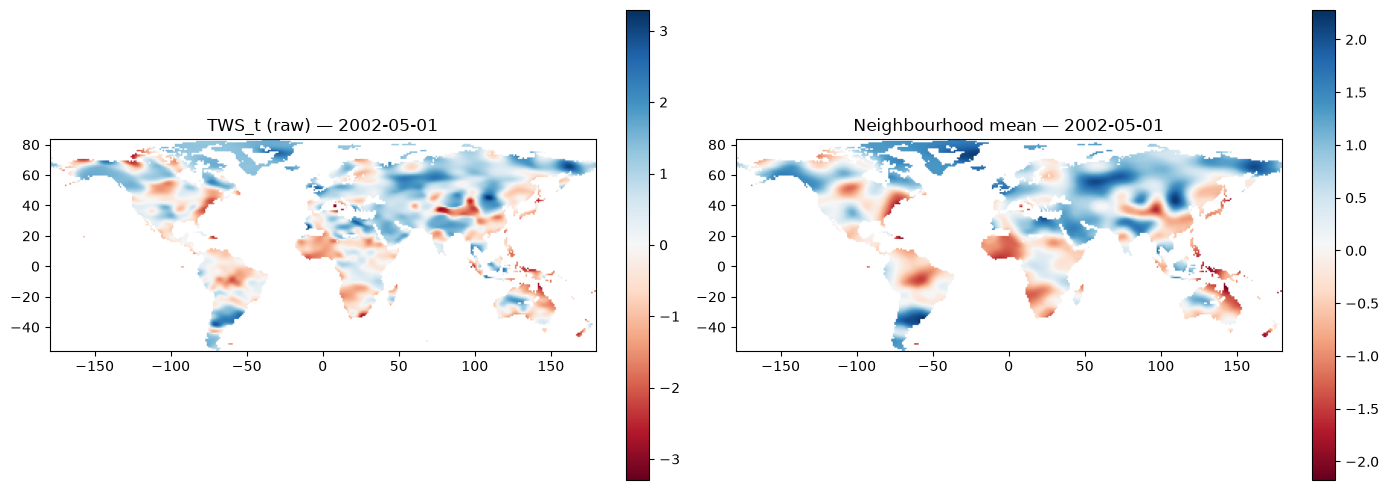

In [5]:
train_nb = add_neighbourhood_features(train, cell_id, adjacency, n_cells)

t0 = train_nb[config.TIME_COL].min()
sub = train_nb.loc[train_nb[config.TIME_COL] == t0, [config.LAT_COL, config.LON_COL, config.TWS_COL, "tws_neighbour_mean"]]
grid_raw = sub.pivot(index=config.LAT_COL, columns=config.LON_COL, values=config.TWS_COL).sort_index().sort_index(axis=1)
grid_nb = sub.pivot(index=config.LAT_COL, columns=config.LON_COL, values="tws_neighbour_mean").sort_index().sort_index(axis=1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax, grid, title in [(axs[0], grid_raw, "TWS_t (raw)"), (axs[1], grid_nb, "Neighbourhood mean")]:
    im = ax.imshow(grid.values, cmap="RdBu", origin="lower",
                    extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()])
    ax.set_title(f"{title} — {str(t0)[:10]}")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


## Controlled validation: baseline features vs. baseline + neighbourhood features

Same chronological split, same model, same fit data - the *only* difference between the two runs below is whether `tws_neighbour_mean`/`tws_local_deviation` are included in the feature matrix.

In [6]:
fit_df, val_df = evaluate.time_train_val_split(train_nb)

candidate_cols = feature_cols + ["tws_neighbour_mean", "tws_local_deviation"]

y_fit = fit_df[config.TARGET_COL].to_numpy()
y_val = val_df[config.TARGET_COL].to_numpy()

results = {}
for name, cols in [("baseline (no neighbours)", feature_cols), ("baseline + neighbourhood features", candidate_cols)]:
    X_fit = features.select_base_features(fit_df, cols)
    X_val = features.select_base_features(val_df, cols)

    m = model.make_baseline_model()
    m.fit(X_fit, y_fit)
    y_pred = model.predict(m, X_val)
    results[name] = evaluate.compute_metrics(y_val, y_pred)

comparison = pd.DataFrame(results).T
comparison["rmse_improvement"] = comparison.loc["baseline (no neighbours)", "rmse"] - comparison["rmse"]
comparison


C:\Users\alher\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\alher\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\alher\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\alher\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\alher\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

,rmse,mae,r2,rmse_improvement
baseline (no neighbours),0.607264,0.428698,0.460179,0.000000
baseline + neighbourhood features,0.599405,0.424034,0.474061,0.007859


## Gate decision

**WIN — graduated to `src/features.py`.** Adding `tws_neighbour_mean` and
`tws_local_deviation` improves every metric component on the same chronological
split, same model, same fit data:

| | RMSE | MAE | R² |
|---|---|---|---|
| baseline (no neighbours) | 0.6073 | 0.4287 | 0.4602 |
| + neighbourhood features | 0.5994 | 0.4240 | 0.4741 |
| improvement | **1.3%** | 1.1% | +0.014 |

Smaller than the masked-fill win (11-14%), but real and consistent — no
regression on any component. The neighbour graph itself is well-conditioned:
87.1 average neighbours per cell within 500 km, only 2 fully isolated cells out
of 15,715 (those two just fall back to the pipeline's median imputer for the
new columns, same as any other NaN).

Graduated: `build_spatial_adjacency()` and `add_neighbourhood_features()` now
live in `src/features.py` (unit-tested on a tiny synthetic 3-cell grid in
`tests/test_features.py`). `src/train.py` builds the adjacency once from the
combined train+test cell set and applies it to both.